In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
"""df_train = pd.read_csv("data/fraudTrain.csv", sep=",",index_col="trans_date_trans_time")
df_test = pd.read_csv("data/fraudTest.csv", sep=",",index_col="trans_date_trans_time")"""

'df_train = pd.read_csv("data/fraudTrain.csv", sep=",",index_col="trans_date_trans_time")\ndf_test = pd.read_csv("data/fraudTest.csv", sep=",",index_col="trans_date_trans_time")'

In [3]:
df = pd.read_csv("data/fraudTrain.csv", sep=",")

In [4]:
df.sample(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1033955,1033955,2020-03-04 04:00:35,4079773899158,fraud_Kuphal-Bartoletti,misc_net,35.05,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,1965-12-15,e127943acec56dbc06ea443e5d4a3117,1362369635,44.209628,-116.485011,0
179587,179587,2019-04-04 01:16:23,5388659976630693,"fraud_Rippin, Kub and Mann",misc_net,6.19,Charles,Preston,M,5364 William Harbor,...,43.2064,-90.9405,153,Quantity surveyor,1962-02-14,f605390f7689e0d61258bca41bb1dd59,1333502183,42.765829,-91.363817,0
669259,669259,2019-10-12 17:08:25,213155997615567,"fraud_Nicolas, Hills and McGlynn",entertainment,83.27,James,Yoder,M,83359 Lopez Point,...,40.5503,-79.3237,168,Race relations officer,1978-10-04,7a93be96e1cd198bc94033f136075581,1350061705,41.207585,-79.509730,0
840993,840993,2019-12-13 21:00:33,38947654498698,fraud_Swift PLC,kids_pets,51.78,Lori,Rodriguez,F,12087 Michael Light,...,39.3543,-82.5030,321,"Copywriter, advertising",1979-06-24,827dadb1f8460c77748c544b226254a1,1355432433,39.630006,-82.402791,0
915794,915794,2019-12-29 23:42:52,3501942333500073,fraud_Ankunding LLC,shopping_net,7.23,Lori,Bishop,F,08056 Alvarado Club Suite 699,...,33.8155,-112.1202,1312922,Counselling psychologist,1999-11-30,fb977206fa0a3e88332d32fa259ed6ba,1356824572,32.918577,-112.552308,0
1116328,1116328,2020-04-09 16:08:08,3596217206093829,"fraud_Walter, Hettinger and Kessler",personal_care,11.32,Sara,Ramirez,F,23843 Scott Island,...,40.8626,-91.9534,888,Camera operator,1988-03-25,7324bc4c4809656abfc39a97473766b3,1365523688,40.789705,-92.751954,0
877146,877146,2019-12-21 19:47:09,6011382886333463,"fraud_Klocko, Runolfsdottir and Breitenberg",health_fitness,97.90,Martin,Duarte,M,6251 Payne Flats Apt. 581,...,44.6001,-84.2931,864,General practice doctor,1942-05-04,f5d80eded0a1e88141f9fa60cb7d2922,1356119229,45.323732,-83.661534,0
645340,645340,2019-10-01 14:04:47,343746486082492,"fraud_Eichmann, Hayes and Treutel",travel,9.84,Jeffrey,Munoz,M,836 Stephanie Union,...,44.8605,-85.8138,3096,"Social research officer, government",1975-10-11,5b3bb864b9c4205d365457c30b82de87,1349100287,44.806244,-86.309899,0
385006,385006,2019-06-25 12:33:29,3523898249167098,fraud_Champlin and Sons,home,32.48,Joshua,Carpenter,M,04975 Allison Shoal,...,40.8798,-73.9067,1382480,"Therapist, drama",1990-11-09,e3c06f6536b7e91bdc27d2f54d3fcdcd,1340627609,41.408863,-74.565522,0
1191106,1191106,2020-05-12 11:31:28,6573561108825071,fraud_Durgan-Auer,misc_net,8.71,Kristina,Lewis,F,5449 Brandi Heights Apt. 111,...,36.2395,-95.9596,413574,Bookseller,1968-06-18,93a6a094b0946cf7efd696daa512391f,1368358288,35.396694,-96.437497,0


In [5]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

On constate qu'on a un dataset très deséquilibrer

In [6]:
df.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

<Axes: ylabel='count'>

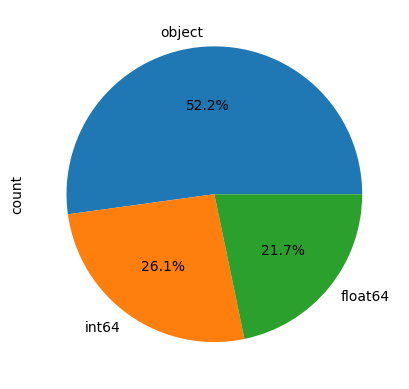

In [7]:
df.dtypes.value_counts().plot.pie(autopct='%1.1f%%')

On constate qu'il y a beaucoup de colonne de type object

In [8]:
df.duplicated().value_counts()

False    1296675
Name: count, dtype: int64

In [9]:
df.describe(include="all")

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1296675,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,...,1.296675e+06,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
unique,NaN,1274791,NaN,693,14,NaN,352,481,2,983,...,NaN,NaN,NaN,494,968,1296675,NaN,NaN,NaN,NaN
top,NaN,2019-04-22 16:02:01,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,864 Reynolds Plains,...,NaN,NaN,NaN,Film/video editor,1977-03-23,0b242abb623afc578575680df30655b9,NaN,NaN,NaN,NaN
freq,NaN,4,NaN,4403,131659,NaN,26669,28794,709863,3123,...,NaN,NaN,NaN,9779,5636,1,NaN,NaN,NaN,NaN
mean,6.483370e+05,NaN,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,...,3.853762e+01,-9.022634e+01,8.882444e+04,NaN,NaN,NaN,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,NaN,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,...,5.075808e+00,1.375908e+01,3.019564e+05,NaN,NaN,NaN,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,NaN,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,...,2.002710e+01,-1.656723e+02,2.300000e+01,NaN,NaN,NaN,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,NaN,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,...,3.462050e+01,-9.679800e+01,7.430000e+02,NaN,NaN,NaN,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,NaN,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,...,3.935430e+01,-8.747690e+01,2.456000e+03,NaN,NaN,NaN,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,NaN,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,...,4.194040e+01,-8.015800e+01,2.032800e+04,NaN,NaN,NaN,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00


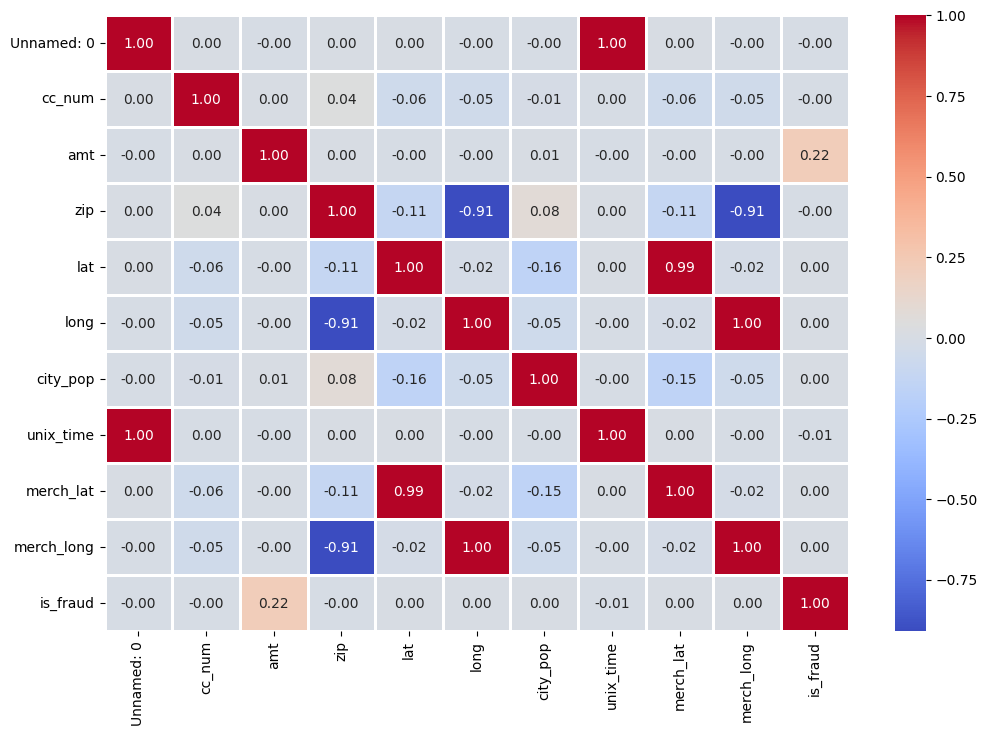

In [10]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
#kot = corr[(corr !=1.000) & ((corr >=0.4) | (corr <=(-0.2)))]
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

In [11]:
df.drop(["unix_time","merch_lat","merch_long","lat","long",'Unnamed: 0','trans_num','cc_num','last','first'], axis=1, inplace=True)

In [12]:
df.describe(include='all')

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,dob,is_fraud
count,1296675,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1296675,1296675,1.296675e+06
unique,1274791,693,14,NaN,2,983,894,51,NaN,NaN,494,968,NaN
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,NaN,F,864 Reynolds Plains,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,NaN
freq,4,4403,131659,NaN,709863,3123,5617,94876,NaN,NaN,9779,5636,NaN
mean,NaN,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,4.880067e+04,8.882444e+04,NaN,NaN,5.788652e-03
std,NaN,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,2.689322e+04,3.019564e+05,NaN,NaN,7.586269e-02
min,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,0.000000e+00
50%,NaN,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,0.000000e+00
75%,NaN,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,7.204200e+04,2.032800e+04,NaN,NaN,0.000000e+00


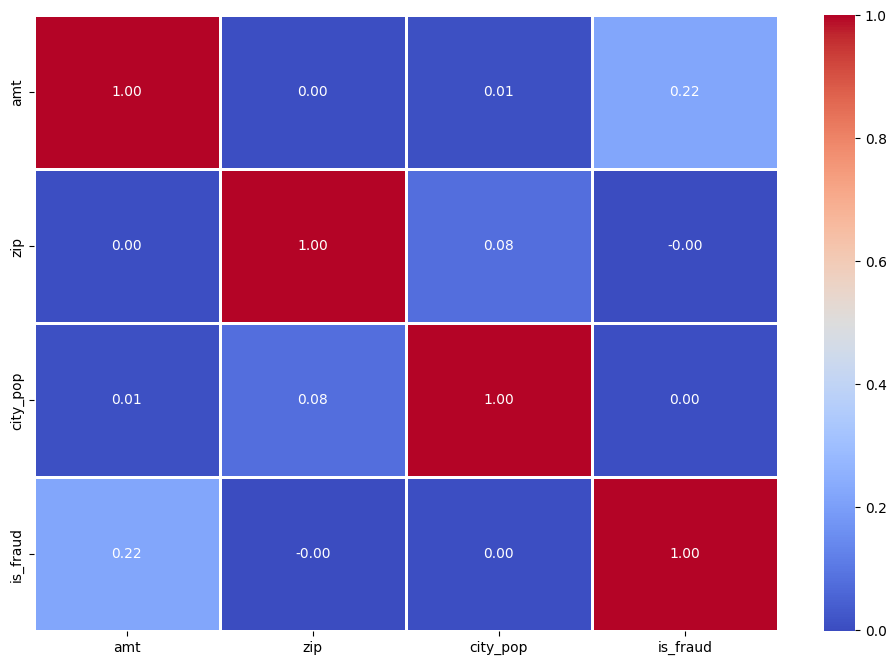

In [13]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

In [14]:
df.sample(5)

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,dob,is_fraud
1088316,2020-03-28 19:47:07,fraud_Weimann-Lockman,kids_pets,42.38,M,45654 Hess Rest,Fort Washakie,WY,82514,1645,Freight forwarder,1976-02-26,0
1127586,2020-04-14 08:35:54,fraud_Barton Inc,grocery_pos,39.40,M,04975 Allison Shoal,Bronx,NY,10463,1382480,"Therapist, drama",1990-11-09,0
949050,2020-01-15 02:17:18,"fraud_Towne, Greenholt and Koepp",shopping_net,102.11,M,39227 Mcpherson Shoals,Lahoma,OK,73754,1078,Podiatrist,1989-10-06,0
378248,2019-06-23 13:02:38,fraud_Schumm PLC,health_fitness,11.78,M,9455 Kathleen Brook Apt. 651,Huslia,AK,99746,277,"Engineer, civil (consulting)",1965-11-06,0
712246,2019-10-31 12:10:22,fraud_Gerhold LLC,home,134.16,F,87665 Karen Mill Apt. 586,Fort Myers,FL,33967,224256,Paramedic,1985-08-29,0


# Pretraitement

In [15]:
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder
from datetime import datetime
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [16]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['age_at_transaction'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['age_at_transaction'] = df['age_at_transaction'].round(0).astype(int)
df['age_at_transaction']

0          31
1          41
2          57
3          52
4          33
           ..
1296670    59
1296671    41
1296672    53
1296673    40
1296674    25
Name: age_at_transaction, Length: 1296675, dtype: int64

<Axes: ylabel='Frequency'>

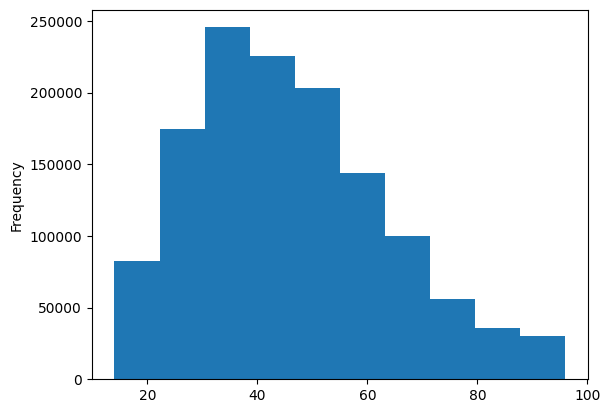

In [17]:
df['age_at_transaction'].plot(kind='hist')

In [18]:
df.drop(["dob"], axis=1, inplace=True)

In [19]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender',
       'street', 'city', 'state', 'zip', 'city_pop', 'job', 'is_fraud',
       'age_at_transaction'],
      dtype='object')

In [20]:
df.sample(4)

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,is_fraud,age_at_transaction
940608,2020-01-10 20:10:39,"fraud_McDermott, Osinski and Morar",home,61.45,F,4511 Choi Lock,Delhi,LA,71232,6581,Multimedia programmer,0,56
665232,2019-10-10 19:59:53,fraud_Reichert-Weissnat,travel,8.74,M,8929 Phillips Corners Suite 259,Harmony,PA,16037,4589,Bookseller,0,63
283987,2019-05-20 00:20:48,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,110.34,M,01892 Patricia Vista Apt. 828,Sachse,TX,75048,20328,Site engineer,0,34
1025227,2020-03-01 04:25:28,fraud_Bashirian Group,shopping_net,4.26,F,6114 Moran Way,Steuben,ME,4680,1131,Make,0,61


In [21]:
y = df["is_fraud"].astype(int)
X = df.drop(columns=["is_fraud"])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ✅ stratification sur la cible
)

In [23]:
numeric_features = ["amt", "zip", "city_pop", "age_at_transaction"]
#categorical_features_ord = ["Sex", "Embarked"]
categorical_features_non_ord = ["state", "city","gender","category","merchant","job"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

"""categorical_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])"""

categorical_non_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinay", OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        #("cat_ord", categorical_ord_transformer, categorical_features_ord),
        ("cat_non_ord", categorical_non_ord_transformer, categorical_features_non_ord),
    ],
    remainder="drop"
)

# Machine Learning

In [24]:
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, auc,roc_auc_score,precision_recall_curve

In [25]:
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=10,            # ratio 99% / 1%
    subsample=0.8,                  # Sous-échantillonnage des lignes
    colsample_bytree=0.8,           # Sous-échantillonnage des colonnes
    eval_metric='aucpr',            # Optimise pour la précision-rappel
    random_state=42
)

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model_xgb)
])

In [26]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_non_ord', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [27]:
X_train

,trans_date_trans_time,merchant,category,amt,gender,street,city,state,zip,city_pop,job,age_at_transaction
509059,2019-08-09 03:13:27,"fraud_Stokes, Christiansen and Sipes",grocery_net,51.71,F,79472 Stevens Trace Apt. 120,Hannawa Falls,NY,13647,69,Chief Executive Officer,28
395295,2019-06-29 19:56:48,fraud_Effertz LLC,entertainment,13.78,F,554 Mcdonald Valley Apt. 539,Meridian,TX,76665,2526,Phytotherapist,49
536531,2019-08-18 14:42:20,fraud_Kris-Padberg,shopping_pos,961.26,F,7202 Jeffrey Mills,Conway,WA,98238,85,"Research officer, political party",35
271001,2019-05-13 21:27:46,fraud_Ratke and Sons,health_fitness,43.68,M,5758 Yates Center,Vinton,CA,96135,128,Education administrator,53
532788,2019-08-17 14:15:41,fraud_Upton PLC,entertainment,33.08,F,852 Thomas Well Suite 339,Owensville,MO,65066,6703,Naval architect,21
...,...,...,...,...,...,...,...,...,...,...,...,...
125527,2019-03-10 21:06:15,"fraud_Effertz, Welch and Schowalter",entertainment,19.70,F,87665 Karen Mill Apt. 586,Fort Myers,FL,33967,224256,Paramedic,34
150047,2019-03-22 05:06:39,fraud_Pacocha-Bauch,shopping_pos,123.45,M,495 Fisher Throughway,Grand Junction,TN,38039,1804,Clothing/textile technologist,44
1151888,2020-04-25 18:11:52,fraud_Abernathy and Sons,food_dining,64.98,F,55363 Aaron Circle Suite 450,Lawn,PA,17041,213,Special educational needs teacher,48
547306,2019-08-22 14:59:38,fraud_Windler LLC,kids_pets,33.65,M,01479 Murray Circle,Matawan,NJ,7747,30770,Drilling engineer,26


In [28]:
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9951
F1-score:  0.6626

Confusion matrix:
 [[256794   1040]
 [   242   1259]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.55      0.84      0.66      1501

    accuracy                           1.00    259335
   macro avg       0.77      0.92      0.83    259335
weighted avg       1.00      1.00      1.00    259335



In [29]:
X_train.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender',
       'street', 'city', 'state', 'zip', 'city_pop', 'job',
       'age_at_transaction'],
      dtype='object')

In [30]:
model_xgb.feature_importances_

array([0.5557857 , 0.01965643, 0.0307236 , 0.04070907, 0.01816006,
       0.02226475, 0.05085284, 0.22670147, 0.01487796, 0.02026811],
      dtype=float32)

In [31]:
column_names = preprocessor.get_feature_names_out()
# 2. On crée la Series avec ces noms
feat_importances = pd.Series(model_xgb.feature_importances_, index=column_names)
print(feat_importances)

num__amt                   0.555786
num__zip                   0.019656
num__city_pop              0.030724
num__age_at_transaction    0.040709
cat_non_ord__state         0.018160
cat_non_ord__city          0.022265
cat_non_ord__gender        0.050853
cat_non_ord__category      0.226701
cat_non_ord__merchant      0.014878
cat_non_ord__job           0.020268
dtype: float32


In [32]:
y_probs = pipe.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

pr_auc = auc(recall, precision)
print(pr_auc)

0.8079679380721668


Rechercher des meilleures hyper parametre avec GridSearch

In [33]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

# Configuration de la validation croisée (essentiel pour le 1% de fraude)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Définition de la grille de recherche
# Note : on utilise 'model__' car c'est le nom dans ta pipeline
param_grid = {
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 200, 300],
    'model__scale_pos_weight': [10, 50, 99],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

# Scoring axé sur la précision/rappel (AUPRC)
scorer = make_scorer(average_precision_score, needs_proba=True)

# Création du GridSearch
grid_search = GridSearchCV(
    estimator=pipe,        # Ta pipeline ici
    param_grid=param_grid,
    scoring=scorer,
    cv=cv_strategy,
    n_jobs=-1,             # Utilise tous les CPU
    verbose=1
)

# Lancement sur tes données
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


c:\Users\Utilisateur\Documents\EFREI\Projets\projet-data-science\projet-detection-fraude\venv\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(a...ds_proba=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosi

In [34]:
# Le meilleur modèle complet (avec preprocessing + meilleurs hyperparamètres)
best_pipeline = grid_search.best_estimator_

# Afficher les meilleurs réglages
print("Meilleurs paramètres trouvés :", grid_search.best_params_)

Meilleurs paramètres trouvés : {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 10, 'model__subsample': 0.8}


In [35]:
# Evaluation du modele optimise
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"Accuracy: {acc_best:.4f}")
print(f"F1-score: {f1_best:.4f}")

roc_auc_best = roc_auc_score(y_test, y_pred_proba_best)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_best)
pr_auc_best = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_best:.4f}")
print(f"PR-AUC: {pr_auc_best:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_best))

Accuracy: 0.9927
F1-score: 0.5139
ROC-AUC: 0.9468
PR-AUC: 0.5385

Confusion matrix:
 [[256432   1402]
 [   497   1004]]


On teste un deuxieme modème Random forest

In [36]:
# Modele 2: Random Forest
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',  # gere le desequilibre
    random_state=42,
    n_jobs=-1  # utilise tous les coeurs CPU
)

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model_rf)
])

pipe_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_non_ord', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [37]:
# Evaluation Random Forest
y_pred_rf = pipe_rf.predict(X_test)
y_pred_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"Accuracy: {acc_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_rf)
pr_auc_rf = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_rf:.4f}")
print(f"PR-AUC: {pr_auc_rf:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9822
F1-score: 0.3676
ROC-AUC: 0.9922
PR-AUC: 0.7218

Confusion matrix:
 [[253362   4472]
 [   156   1345]]


In [38]:
# Modele 3: Logistic Regression
model_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

pipe_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model_lr)
])

pipe_lr.fit(X_train, y_train)

c:\Users\Utilisateur\Documents\EFREI\Projets\projet-data-science\projet-detection-fraude\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_non_ord', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [39]:
# Evaluation Logistic Regression
y_pred_lr = pipe_lr.predict(X_test)
y_pred_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"Accuracy: {acc_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")

roc_auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_lr)
pr_auc_lr = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_lr:.4f}")
print(f"PR-AUC: {pr_auc_lr:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.9488
F1-score: 0.1468
ROC-AUC: 0.8555
PR-AUC: 0.2029

Confusion matrix:
 [[244919  12915]
 [   359   1142]]


In [40]:
# Comparaison des 3 modeles supervises
import pandas as pd

resultats = pd.DataFrame({
    'Modele': ['XGBoost (optimise)', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [acc_best, acc_rf, acc_lr],
    'F1-Score': [f1_best, f1_rf, f1_lr],
    'ROC-AUC': [roc_auc_best, roc_auc_rf, roc_auc_lr],
    'PR-AUC': [pr_auc_best, pr_auc_rf, pr_auc_lr]
})

print(resultats.to_string(index=False))

             Modele  Accuracy  F1-Score  ROC-AUC   PR-AUC
 XGBoost (optimise)  0.992677  0.513949 0.946799 0.538504
      Random Forest  0.982154  0.367587 0.992233 0.721811
Logistic Regression  0.948815  0.146806 0.855536 0.202871


In [41]:
# Test avec SMOTE pour gerer le desequilibre
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Pipeline avec SMOTE
model_xgb_smote = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
)

pipe_smote = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", model_xgb_smote)
])

pipe_smote.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_non_ord', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formattin

In [42]:
# Evaluation XGBoost avec SMOTE
y_pred_smote = pipe_smote.predict(X_test)
y_pred_proba_smote = pipe_smote.predict_proba(X_test)[:, 1]

acc_smote = accuracy_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print(f"Accuracy: {acc_smote:.4f}")
print(f"F1-score: {f1_smote:.4f}")

roc_auc_smote = roc_auc_score(y_test, y_pred_proba_smote)
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba_smote)
pr_auc_smote = auc(recall, precision)

print(f"ROC-AUC: {roc_auc_smote:.4f}")
print(f"PR-AUC: {pr_auc_smote:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_smote))

Accuracy: 0.9611
F1-score: 0.1854
ROC-AUC: 0.8959
PR-AUC: 0.4050

Confusion matrix:
 [[248109   9725]
 [   354   1147]]
